# Classroom Reaction Recognition

**ResNet18 vs VGG16 Transfer Learning Comparison**

This notebook trains and evaluates two CNN architectures on a 5-class facial reaction dataset:
- **Neutral** -- no visible expression
- **Confused** -- furrowed brow, squinting
- **Smiling_Amused** -- visible smile, laughter
- **Surprised** -- raised eyebrows, open mouth
- **Bored_Tired** -- yawning, blank stare

Dataset was extracted from classroom lecture videos using YOLOv8 person detection and split 70/10/20.

## 1. Environment Setup

In [ ]:
pip install -q torch torchvision scikit-learn matplotlib seaborn pandas huggingface_hub

In [66]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Mount Google Drive & Load Dataset

Upload `reaction_dataset.zip` to your Google Drive root or a folder, then update the path below.

In [67]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
import zipfile
from pathlib import Path

DATA_DIR = Path("/content/data/crops")
DRIVE_ZIP = Path("/content/drive/MyDrive/reaction_dataset.zip")

import shutil

shutil.rmtree("/content/data", ignore_errors=True)

print("Extracting with path fix...")
with zipfile.ZipFile(str(DRIVE_ZIP), "r") as z:
    for info in z.infolist():
        fixed = info.filename.replace("\\", "/")
        target = DATA_DIR / fixed
        if info.is_dir():
            target.mkdir(parents=True, exist_ok=True)
        else:
            target.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(target, "wb") as dst:
                dst.write(src.read())
print("Done.")

for split in ["train", "val", "test"]:
    split_dir = DATA_DIR / split
    if split_dir.exists():
        classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        counts = {c: len(list((split_dir / c).glob("*.jpg"))) for c in classes}
        print(f"{split:>5}: {sum(counts.values()):>4} images  {counts}")
    else:
        print(f"{split:>5}: MISSING!")

Extracting with path fix...
Done.
train:  499 images  {'Bored_Tired': 34, 'Confused': 20, 'Neutral': 326, 'Smiling_Amused': 107, 'Surprised': 12}
  val:   71 images  {'Bored_Tired': 5, 'Confused': 3, 'Neutral': 46, 'Smiling_Amused': 15, 'Surprised': 2}
 test:  144 images  {'Bored_Tired': 10, 'Confused': 5, 'Neutral': 95, 'Smiling_Amused': 31, 'Surprised': 3}


## 3. Configuration & Data Loading

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
torch.manual_seed(SEED)

CLASS_NAMES = ["Bored_Tired", "Confused", "Neutral", "Smiling_Amused", "Surprised"]
NUM_CLASSES = len(CLASS_NAMES)
INPUT_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 0.001

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [70]:
train_tf = transforms.Compose(
    [
        transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)
val_tf = transforms.Compose(
    [
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

train_dataset = datasets.ImageFolder(str(DATA_DIR / "train"), transform=train_tf)
val_dataset = datasets.ImageFolder(str(DATA_DIR / "val"), transform=val_tf)
test_dataset = datasets.ImageFolder(str(DATA_DIR / "test"), transform=val_tf)

train_loader = None  # created after class weights in next cell
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

print(
    f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}"
)
print(f"Classes (ImageFolder order): {train_dataset.classes}")

Train: 499  Val: 71  Test: 144
Classes (ImageFolder order): ['Bored_Tired', 'Confused', 'Neutral', 'Smiling_Amused', 'Surprised']


In [71]:
counts = Counter(train_dataset.targets)
total = len(train_dataset.targets)
num_c = len(counts)
class_weights = torch.FloatTensor(
    [total / (num_c * counts[i]) for i in range(num_c)]
).to(device)

print("Class counts :", dict(counts))
print("Class weights:", [round(w.item(), 3) for w in class_weights])

targets = torch.tensor(train_dataset.targets)
sample_weights = class_weights.cpu()[targets]
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(train_dataset) * 2,
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
)

criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Sampler will draw {len(sampler)} samples per epoch (2x oversampling)")

Class counts : {0: 34, 1: 20, 2: 326, 3: 107, 4: 12}
Class weights: [2.935, 4.99, 0.306, 0.933, 8.317]
Sampler will draw 998 samples per epoch (2x oversampling)


## 4. Model Definitions

In [72]:
def build_resnet18(num_classes, device):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def build_vgg16(num_classes, device):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model.to(device)

## 5. Training Loop

In [73]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def train_model(name, model, train_loader, val_loader, criterion, device, lr, epochs):
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=3,
        factor=0.5,
    )
    best_val_acc = 0.0
    best_weights = None
    history = []

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"\n{'=' * 60}")
    print(f"Training {name} for {epochs} epochs")
    print(f"  Trainable params: {trainable:,} / {total:,}")
    print(f"{'=' * 60}\n")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_acc)

        tag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            tag = "  <-- best"

        cur_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"LR: {cur_lr:.6f} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f}{tag}"
        )
        history.append([epoch, train_loss, train_acc, val_loss, val_acc])

    print(f"\n{name} complete. Best Val Accuracy: {best_val_acc:.3f}")
    return best_weights, history

## 6. Train ResNet18

In [74]:
resnet = build_resnet18(NUM_CLASSES, device)
resnet_weights, resnet_history = train_model(
    "ResNet18", resnet, train_loader, val_loader, criterion, device, LR, EPOCHS
)


Training ResNet18 for 20 epochs
  Trainable params: 8,396,293 / 11,179,077

Epoch 01/20 | LR: 0.001000 | Train Loss: 0.6679  Acc: 0.546 | Val Loss: 2.3574  Acc: 0.310  <-- best
Epoch 02/20 | LR: 0.001000 | Train Loss: 0.2049  Acc: 0.738 | Val Loss: 2.6353  Acc: 0.268
Epoch 03/20 | LR: 0.001000 | Train Loss: 0.1285  Acc: 0.819 | Val Loss: 2.3490  Acc: 0.338  <-- best
Epoch 04/20 | LR: 0.001000 | Train Loss: 0.1230  Acc: 0.820 | Val Loss: 2.6651  Acc: 0.521  <-- best
Epoch 05/20 | LR: 0.001000 | Train Loss: 0.1160  Acc: 0.844 | Val Loss: 2.4203  Acc: 0.310
Epoch 06/20 | LR: 0.001000 | Train Loss: 0.1420  Acc: 0.825 | Val Loss: 2.5070  Acc: 0.549  <-- best
Epoch 07/20 | LR: 0.001000 | Train Loss: 0.0741  Acc: 0.877 | Val Loss: 2.4342  Acc: 0.634  <-- best
Epoch 08/20 | LR: 0.001000 | Train Loss: 0.1414  Acc: 0.856 | Val Loss: 2.2181  Acc: 0.493
Epoch 09/20 | LR: 0.001000 | Train Loss: 0.1164  Acc: 0.871 | Val Loss: 3.5229  Acc: 0.394
Epoch 10/20 | LR: 0.001000 | Train Loss: 0.1110  Acc: 

## 7. Train VGG16

In [75]:
vgg = build_vgg16(NUM_CLASSES, device)
vgg_weights, vgg_history = train_model(
    "VGG16", vgg, train_loader, val_loader, criterion, device, LR, EPOCHS
)


Training VGG16 for 20 epochs
  Trainable params: 119,566,341 / 134,281,029

Epoch 01/20 | LR: 0.001000 | Train Loss: 1.5949  Acc: 0.359 | Val Loss: 3.2720  Acc: 0.113  <-- best
Epoch 02/20 | LR: 0.001000 | Train Loss: 0.8218  Acc: 0.550 | Val Loss: 2.8603  Acc: 0.197  <-- best
Epoch 03/20 | LR: 0.001000 | Train Loss: 0.8745  Acc: 0.665 | Val Loss: 3.3264  Acc: 0.408  <-- best
Epoch 04/20 | LR: 0.001000 | Train Loss: 0.7011  Acc: 0.668 | Val Loss: 5.8764  Acc: 0.239
Epoch 05/20 | LR: 0.001000 | Train Loss: 0.6895  Acc: 0.706 | Val Loss: 4.8261  Acc: 0.352
Epoch 06/20 | LR: 0.001000 | Train Loss: 0.7692  Acc: 0.710 | Val Loss: 7.5953  Acc: 0.465  <-- best
Epoch 07/20 | LR: 0.001000 | Train Loss: 0.6395  Acc: 0.740 | Val Loss: 9.1605  Acc: 0.310
Epoch 08/20 | LR: 0.001000 | Train Loss: 0.9969  Acc: 0.731 | Val Loss: 8.6236  Acc: 0.254
Epoch 09/20 | LR: 0.001000 | Train Loss: 0.8332  Acc: 0.722 | Val Loss: 10.9292  Acc: 0.310
Epoch 10/20 | LR: 0.000500 | Train Loss: 1.5060  Acc: 0.721 | V

## 8. Training Curves -- ResNet18 vs VGG16

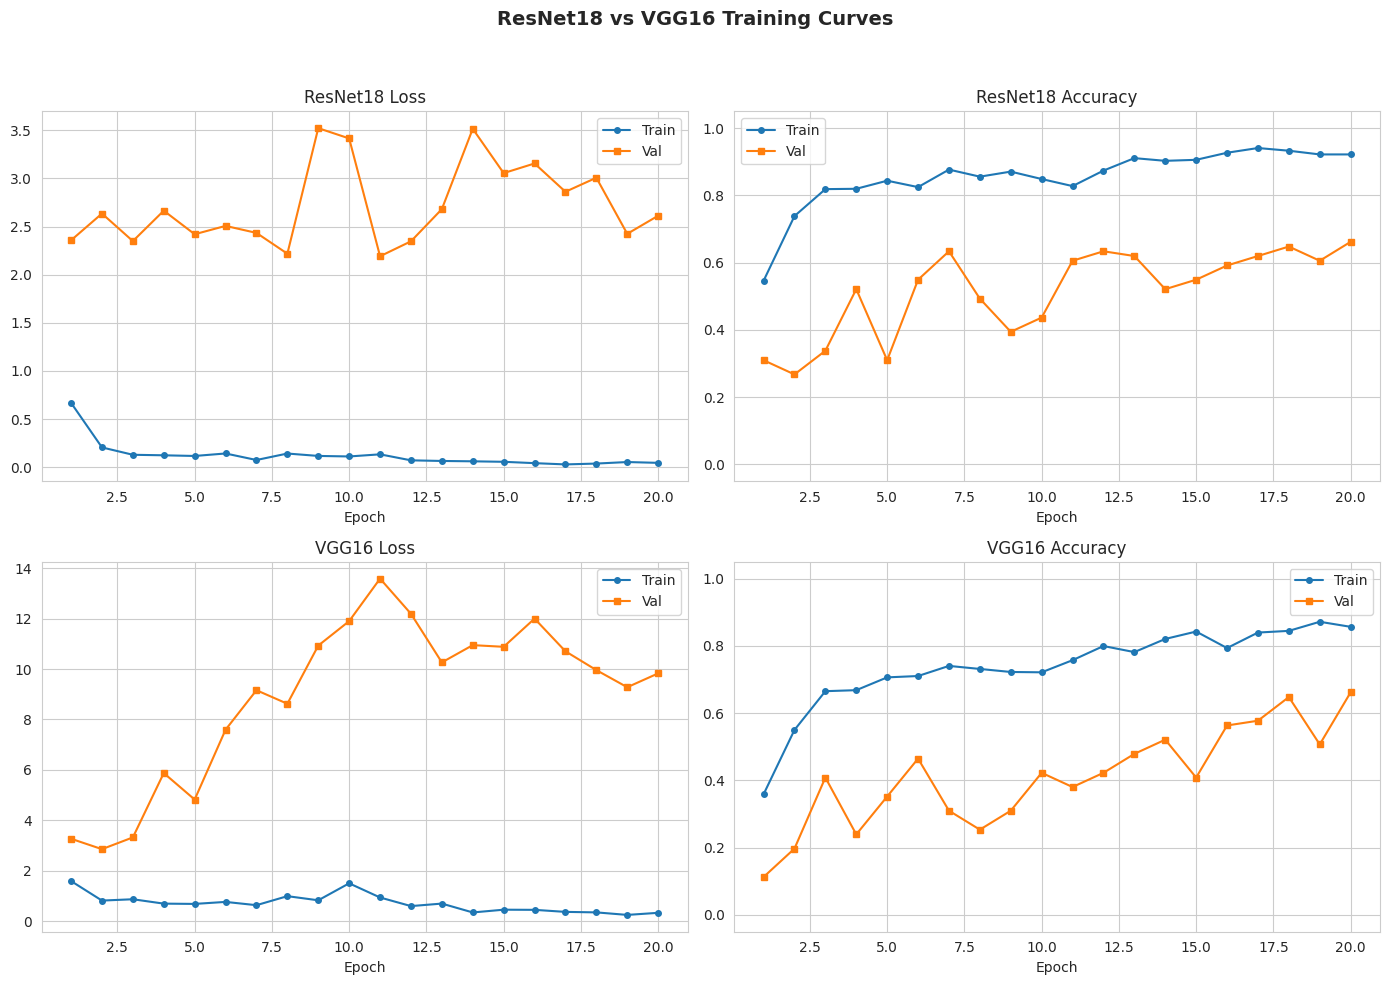

In [76]:
def plot_history(history, name, axes_row):
    epochs_col = [h[0] for h in history]
    ax_loss, ax_acc = axes_row
    ax_loss.plot(epochs_col, [h[1] for h in history], "o-", ms=4, label="Train")
    ax_loss.plot(epochs_col, [h[3] for h in history], "s-", ms=4, label="Val")
    ax_loss.set_title(f"{name} Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.legend()
    ax_acc.plot(epochs_col, [h[2] for h in history], "o-", ms=4, label="Train")
    ax_acc.plot(epochs_col, [h[4] for h in history], "s-", ms=4, label="Val")
    ax_acc.set_title(f"{name} Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylim(-0.05, 1.05)
    ax_acc.legend()


sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_history(resnet_history, "ResNet18", axes[0])
plot_history(vgg_history, "VGG16", axes[1])
fig.suptitle("ResNet18 vs VGG16 Training Curves", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 9. Evaluation on Test Set

In [77]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_true, all_pred = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_true.extend(labels.numpy())
        all_pred.extend(preds.cpu().numpy())
    return np.array(all_true), np.array(all_pred)


def evaluate_and_plot(model, weights, name, loader, class_names, device):
    model.load_state_dict({k: v.to(device) for k, v in weights.items()})
    y_true, y_pred = collect_predictions(model, loader, device)

    print(f"\n{'=' * 60}")
    print(f"{name} -- Test Set Evaluation")
    print(f"{'=' * 60}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
    }


ResNet18 -- Test Set Evaluation
                precision    recall  f1-score   support

   Bored_Tired       0.42      0.50      0.45        10
      Confused       0.29      0.80      0.42         5
       Neutral       0.91      0.72      0.80        95
Smiling_Amused       0.62      0.77      0.69        31
     Surprised       0.25      0.33      0.29         3

      accuracy                           0.71       144
     macro avg       0.49      0.62      0.53       144
  weighted avg       0.77      0.71      0.73       144



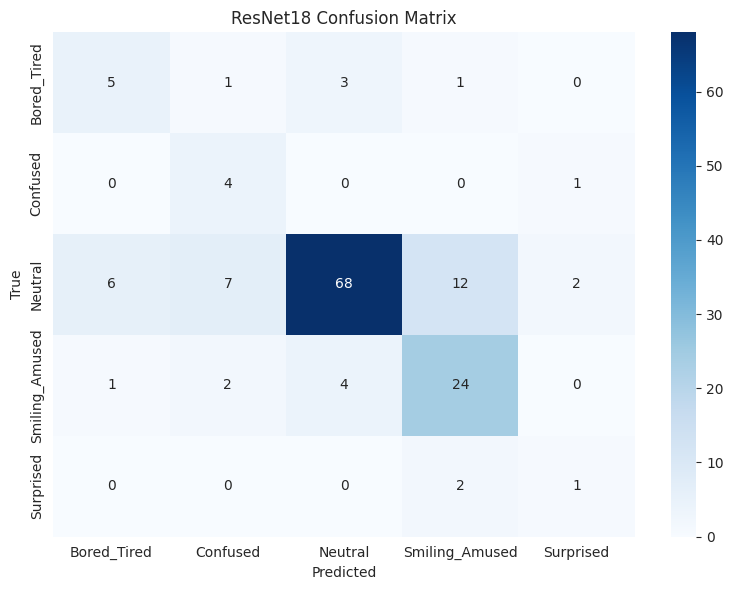

In [78]:
resnet_eval = build_resnet18(NUM_CLASSES, device)
r_metrics = evaluate_and_plot(
    resnet_eval, resnet_weights, "ResNet18", test_loader, CLASS_NAMES, device
)


VGG16 -- Test Set Evaluation
                precision    recall  f1-score   support

   Bored_Tired       0.33      0.20      0.25        10
      Confused       0.30      0.60      0.40         5
       Neutral       0.76      0.80      0.78        95
Smiling_Amused       0.53      0.32      0.40        31
     Surprised       0.11      0.33      0.17         3

      accuracy                           0.64       144
     macro avg       0.41      0.45      0.40       144
  weighted avg       0.65      0.64      0.64       144



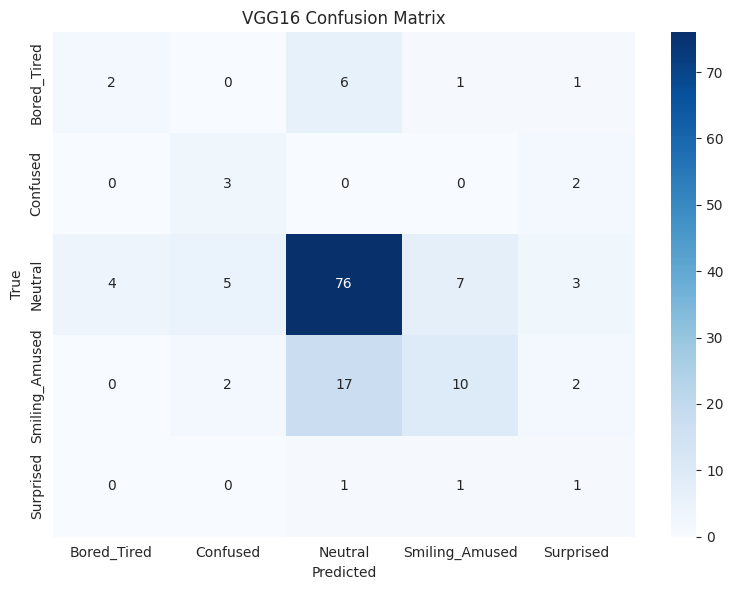

In [79]:
vgg_eval = build_vgg16(NUM_CLASSES, device)
v_metrics = evaluate_and_plot(
    vgg_eval, vgg_weights, "VGG16", test_loader, CLASS_NAMES, device
)

## 10. Side-by-Side Model Comparison

          accuracy  precision  recall     f1
model                                       
ResNet18    0.7083     0.7747  0.7083 0.7275
VGG16       0.6389     0.6506  0.6389 0.6351



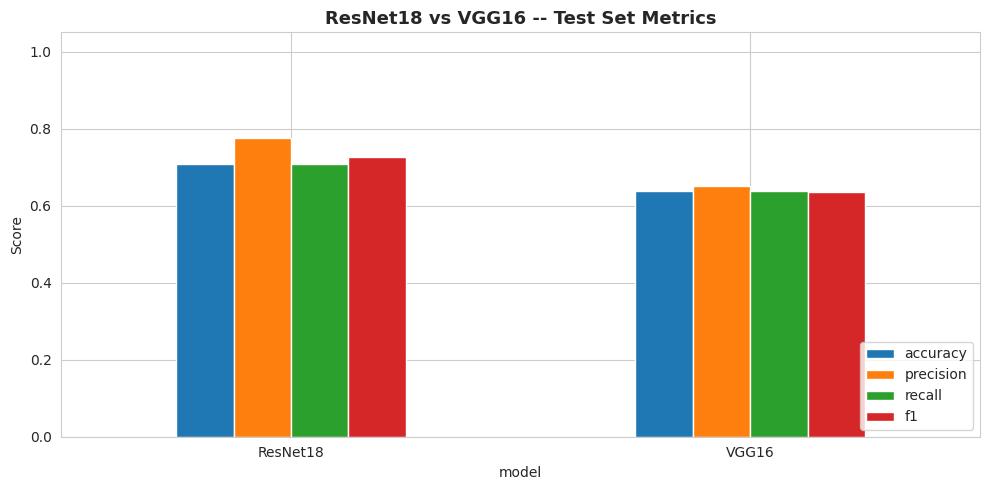

In [80]:
import pandas as pd

comparison = pd.DataFrame([r_metrics, v_metrics])
comparison = comparison.set_index("model")
print(comparison.to_string(float_format="{:.4f}".format))
print()

comparison.plot(kind="bar", figsize=(10, 5), ylim=(0, 1.05), rot=0)
plt.title("ResNet18 vs VGG16 -- Test Set Metrics", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Save Weights and CSVs to Google Drive

In [84]:
import csv

save_dir = Path("/content/drive/MyDrive/Reaction_Results")
save_dir.mkdir(parents=True, exist_ok=True)

torch.save(resnet_weights, str(save_dir / "best_resnet18.pth"))
torch.save(vgg_weights, str(save_dir / "best_vgg16.pth"))

comparison.to_csv(str(save_dir / "model_comparison.csv"))

for name, history in [("resnet18", resnet_history), ("vgg16", vgg_history)]:
    with open(save_dir / f"history_{name}.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])
        writer.writerows(history)
    print(f"Saved history_{name}.csv")

print(f"Weights and comparison saved to {save_dir}")

Saved history_resnet18.csv
Saved history_vgg16.csv
Weights and comparison saved to /content/drive/MyDrive/Reaction_Results


## 12. Upload models to huggingface

In [86]:
from huggingface_hub import HfApi, login
from pathlib import Path

login()  # paste your HF token when prompted

api = HfApi()
save_dir = Path("/content/drive/MyDrive/Reaction_Results")

print("Uploading ResNet18...")
api.upload_file(
    path_or_fileobj=str(save_dir / "best_resnet18.pth"),
    path_in_repo="best_resnet18.pth",
    repo_id="ummanmm/classroom-reaction-resnet18",
)

print("Uploading VGG16...")
api.upload_file(
    path_or_fileobj=str(save_dir / "best_vgg16.pth"),
    path_in_repo="best_vgg16.pth",
    repo_id="ummanmm/classroom-reaction-vgg16",
)

print("Done! Both models uploaded to Hugging Face.")

Uploading ResNet18...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...Results/best_resnet18.pth:   1%|1         |  565kB / 44.8MB            

Uploading VGG16...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...on_Results/best_vgg16.pth:   3%|3         | 18.7MB /  537MB            

Done! Both models uploaded to Hugging Face.
